In [1]:
import this


The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


In [5]:
print("Hello, world!")

Hello, world!


In [13]:
type(df)

pandas.core.frame.DataFrame

In [19]:
repr("Hello, world!")

"'Hello, world!'"

In [18]:
print("Hello, world!")

Hello, world!


In [ ]:
def myfunction():
    return 1

In [6]:
import requests
from pathlib import Path
r = requests.get(
    "https://cdn.lazarev.fun/data/"
    "const_vdv_pretty_with_mw_volume.tsv"
)
Path("const_vdv_pretty_with_mw_volume.tsv") \
    .write_text(r.content.decode("utf-8"))

1541

In [8]:
import pandas as pd
df = pd.read_csv(
    "const_vdv_pretty_with_mw_volume.tsv",
    sep="\t"
)

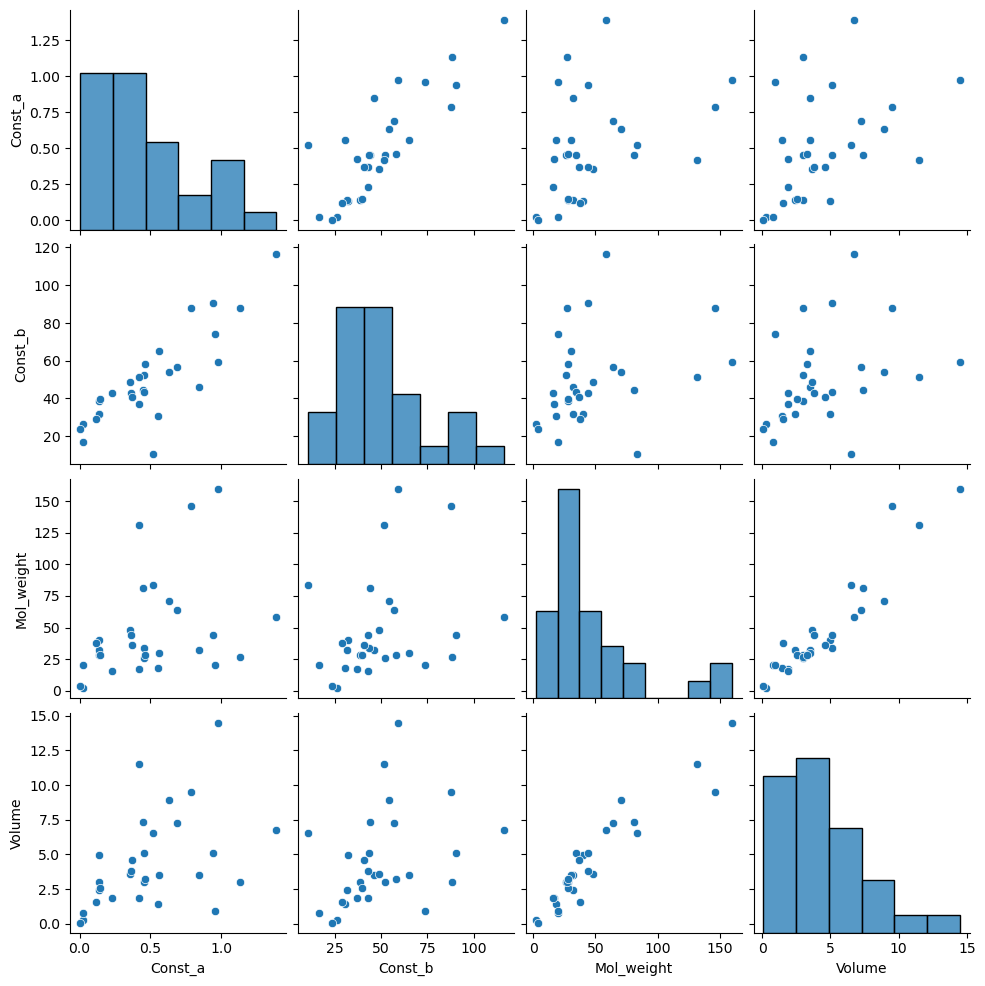

In [9]:
%pip install seaborn
import seaborn
seaborn.pairplot(df)
import matplotlib.pyplot as plt
plt.show()

In [20]:
df.head(1)

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume
0,Азот,N2,0.137,38.7,28.014,2.998428


<Axes: xlabel='Volume', ylabel='Mol_weight'>

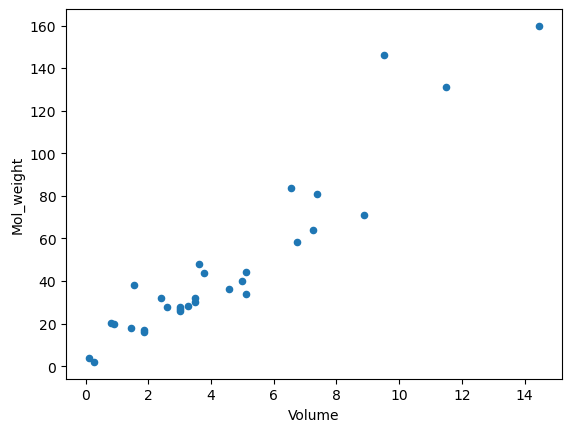

In [31]:
df.plot(x="Volume", y="Mol_weight", kind="scatter")

In [32]:
%pip install scikit-learn

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
reg = LinearRegression()

In [37]:
type(df[["Volume"]]), type(df["Volume"])

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [39]:
df[["Volume"]].head(1)

,Volume
0,2.998428


In [41]:
df["Volume"][:5]

0     2.998428
1     1.873579
2     4.988916
3     3.001687
4    14.476459
Name: Volume, dtype: float64

In [44]:
reg.fit(df[["Volume"]], df["Mol_weight"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
reg.coef_, reg.intercept_

(array([10.81328346]), np.float64(-0.8267534529862743))

In [46]:
df["Mol_weight_pred"] = (
    df.Volume * reg.coef_[0] + reg.intercept_
)

<Axes: xlabel='Volume'>

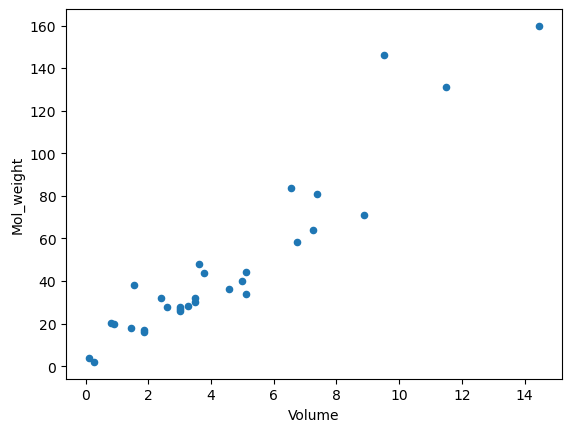

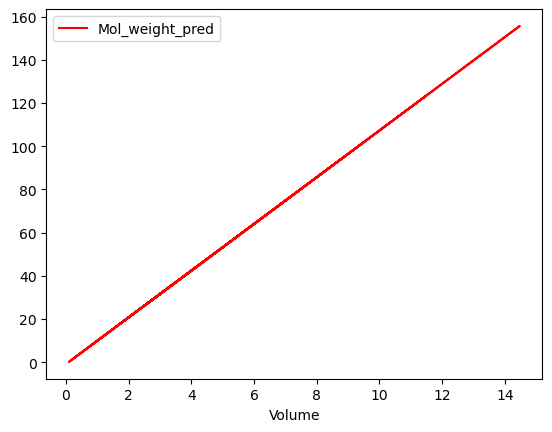

In [71]:
df.plot(x="Volume", y="Mol_weight", kind="scatter")
df.plot(x="Volume", y="Mol_weight_pred", kind="line", color="red") 

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

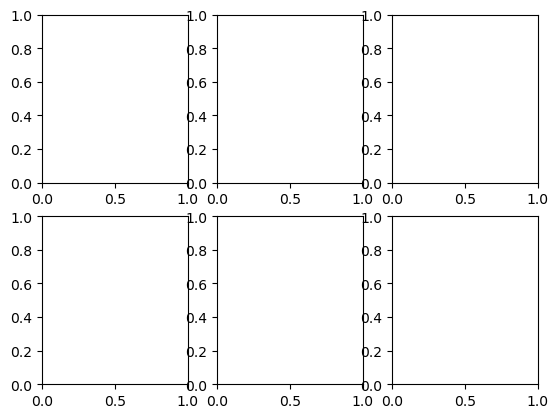

In [73]:
plt.subplots(2, 3)[1]

<Axes: xlabel='Volume', ylabel='Mol_weight'>

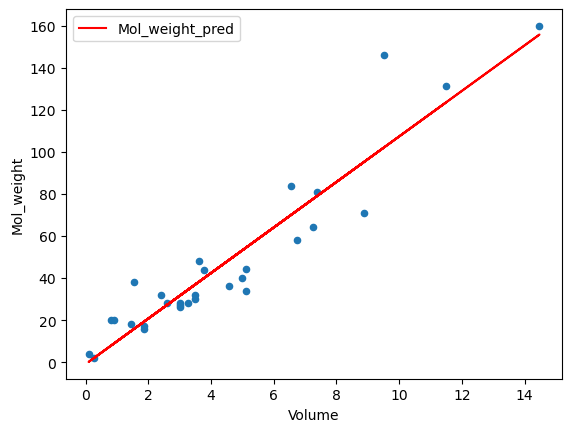

In [72]:
_, ax = plt.subplots(1, 1)
df.plot(
    x="Volume", y="Mol_weight", kind="scatter", ax=ax
)
df.plot(
    x="Volume", y="Mol_weight_pred", kind="line", ax=ax, color="red"
) 

In [74]:
df["Mol_weight_pred_err"] = df["Mol_weight_pred"] - df["Mol_weight"]

<Axes: ylabel='Frequency'>

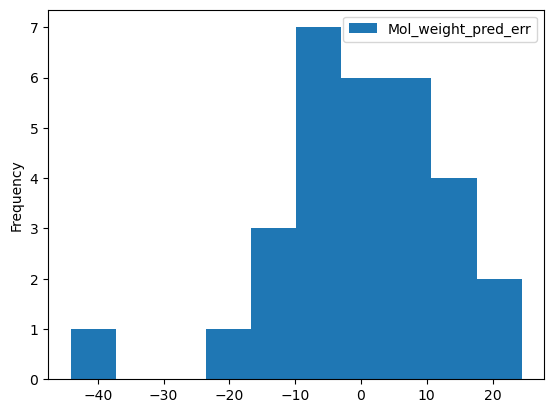

In [76]:
df.plot(y="Mol_weight_pred_err", kind="hist")

In [77]:
df[df.Mol_weight_pred_err < -30]

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume,Mol_weight_pred,Mol_weight_pred_err
9,Гексафторид серы,SF6,0.7857,87.9,146.06,9.503456,101.93681,-44.12319


In [88]:
# df[df.Mol_weight_pred_err > -30]
df[df.Formula != "SF6"]["Mol_weight_pred_err"].std()

np.float64(10.628139244283343)

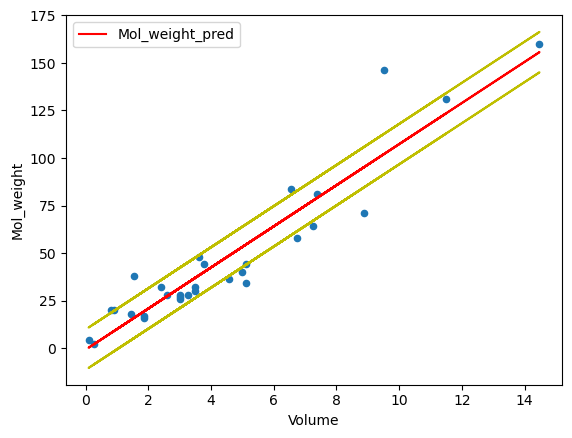

In [89]:
_, ax = plt.subplots(1, 1)
df.plot(
    x="Volume", y="Mol_weight", kind="scatter", ax=ax
)
df.plot(
    x="Volume", y="Mol_weight_pred", kind="line", ax=ax, color="red"
)

reg_std = df[df.Formula != "SF6"]\
    ["Mol_weight_pred_err"].std()

ax.plot(
    df["Volume"], 
    df["Mol_weight_pred"] + reg_std,
    "y"
)

ax.plot(
    df["Volume"], 
    df["Mol_weight_pred"] - reg_std,
    "y"
)

In [91]:
df[df["Mol_weight_pred_err"].abs() > reg_std].head(1)

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume,Mol_weight_pred,Mol_weight_pred_err
2,Аргон,Ar,0.1355,32.0,39.9,4.988916,53.119811,13.219811


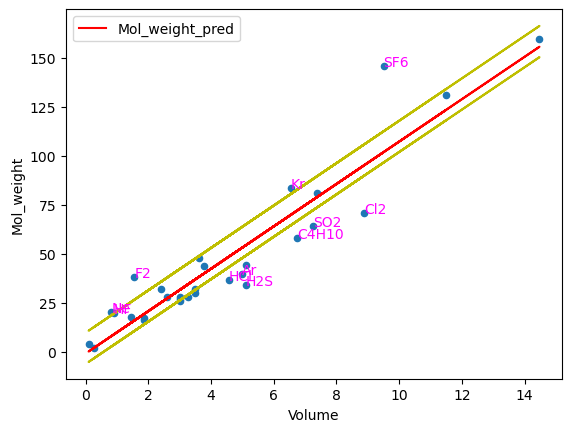

In [104]:
_, ax = plt.subplots(1, 1)
df.plot(
    x="Volume", y="Mol_weight", kind="scatter", ax=ax
)
df.plot(
    x="Volume", y="Mol_weight_pred", kind="line", ax=ax, color="red"
)

reg_std = df[df.Formula != "SF6"]\
    ["Mol_weight_pred_err"].std()

ax.plot(
    df["Volume"], 
    df["Mol_weight_pred"] + reg_std,
    "y"
)

ax.plot(
    df["Volume"], 
    df["Mol_weight_pred"] - 0.5 * reg_std,
    "y"
)
df_outs = df[df["Mol_weight_pred_err"].abs() > reg_std]
for v, m, f in df_outs[["Volume", "Mol_weight", "Formula"]].values:
    ax.text(v, m, f, color="magenta")

